# Motion Planning — Question 1

The goal of this task is to understand why a normal grid-based A* planner is not sufficient for a car-like vehicle.

I first study the buggy's configuration space and minimum turning radius. I then implement a normal 2D A* planner on a road-like grid, visualize its path, and check whether the resulting turns are physically executable by the buggy.

Finally, I discuss how a more vehicle-aware planner such as Hybrid A* and a better cost function can account for steering, curvature, obstacle clearance and passenger comfort.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import math

## A. Configuration space of the buggy

A point robot moving on a flat plane can be represented only by its position:

\[
(x,y)
\]

For the buggy, position alone is not enough because the vehicle also has a heading.

Therefore, a simple planar configuration is:

\[
(x,y,\theta)
\]

where:

- \(x\): horizontal position
- \(y\): vertical position
- \(\theta\): vehicle heading

This makes the configuration space three-dimensional.

The difference matters because a point robot can move from one grid cell to any neighbouring free cell without considering orientation. A car-like vehicle cannot rotate on the spot. Its next position depends on its current heading and steering angle.

Therefore, a path that is collision-free for a point robot may still be impossible for the buggy to follow.

In [2]:
wheelbase = 2.30
max_steer_deg = 32

max_steer_rad = math.radians(max_steer_deg)

min_turning_radius = wheelbase / math.tan(max_steer_rad)

print("Minimum turning radius =", round(min_turning_radius, 2), "m")

Minimum turning radius = 3.68 m


## B. Minimum turning radius

Using the bicycle-model relationship,

\[
R_{min}=\frac{L}{\tan(\delta_{max})}
\]

with:

\[
L=2.30m
\]

and

\[
\delta_{max}=32^\circ
\]

the minimum turning radius is approximately:

\[
R_{min}\approx 3.68m
\]

This means the buggy cannot execute an arbitrarily sharp corner.

A normal grid-based A* planner does not know this constraint. It may return a path containing a sudden 90-degree change in direction between neighbouring cells.

Such a path is valid for a point robot but physically impossible for the buggy because the buggy would need to rotate almost instantaneously at the corner.

## C. Why Hybrid A* is more suitable

Normal grid A* searches over discrete grid cells such as \((x,y)\).

Hybrid A* also considers vehicle heading, so its state is closer to:

\[
(x,y,\theta)
\]

Instead of expanding arbitrary neighbouring cells, it generates successor states using motion that resembles the kinematics of a car.

This means the generated path already respects the fact that the vehicle cannot move sideways or turn on the spot.

Hybrid A* therefore tends to produce smoother and physically executable paths for car-like vehicles, although it is computationally more expensive than normal grid A*.

In [3]:
def heuristic(a, b):
    return math.sqrt(
        (a[0] - b[0])**2 +
        (a[1] - b[1])**2
    )


def astar(grid, start, goal):

    rows, cols = grid.shape

    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1),

        (-1, -1),
        (-1, 1),
        (1, -1),
        (1, 1)
    ]

    open_list = []

    heapq.heappush(
        open_list,
        (0, start)
    )

    came_from = {}

    g_cost = {
        start: 0
    }

    explored = []

    while open_list:

        current_f, current = heapq.heappop(
            open_list
        )

        explored.append(current)

        if current == goal:
            break


        for dx, dy in directions:

            neighbour = (
                current[0] + dx,
                current[1] + dy
            )

            x, y = neighbour

            if x < 0 or x >= rows:
                continue

            if y < 0 or y >= cols:
                continue

            if grid[x, y] == 1:
                continue


            if dx != 0 and dy != 0:
                move_cost = math.sqrt(2)

            else:
                move_cost = 1


            new_cost = (
                g_cost[current]
                + move_cost
            )


            if (
                neighbour not in g_cost
                or
                new_cost < g_cost[neighbour]
            ):

                g_cost[neighbour] = new_cost

                priority = (
                    new_cost
                    + heuristic(
                        neighbour,
                        goal
                    )
                )

                heapq.heappush(
                    open_list,
                    (priority, neighbour)
                )

                came_from[neighbour] = current


    if goal not in came_from:
        return None, explored


    path = [goal]

    current = goal

    while current != start:

        current = came_from[current]

        path.append(current)


    path.reverse()

    return path, explored

## D. Testing normal A* on a road-like environment

I now test the grid-based A* planner on a simple road-like environment.

The grid contains:
- a start position,
- a goal position,
- a bend in the road,
- and several static obstacles.

The planner treats the buggy as a point and searches for the shortest collision-free path through the free grid cells.

In [4]:
grid = np.zeros((30, 40))

# obstacle 1
grid[5:20, 12:15] = 1

# obstacle 2
grid[17:20, 15:28] = 1

# obstacle 3
grid[5:15, 27:30] = 1

# obstacle 4
grid[23:27, 20:24] = 1

start = (25, 3)
goal = (4, 35)

path, explored = astar(grid, start, goal)

print("Path found:", path is not None)
print("Path length in grid points:", len(path))
print("Explored states:", len(explored))

Path found: True
Path length in grid points: 41
Explored states: 561


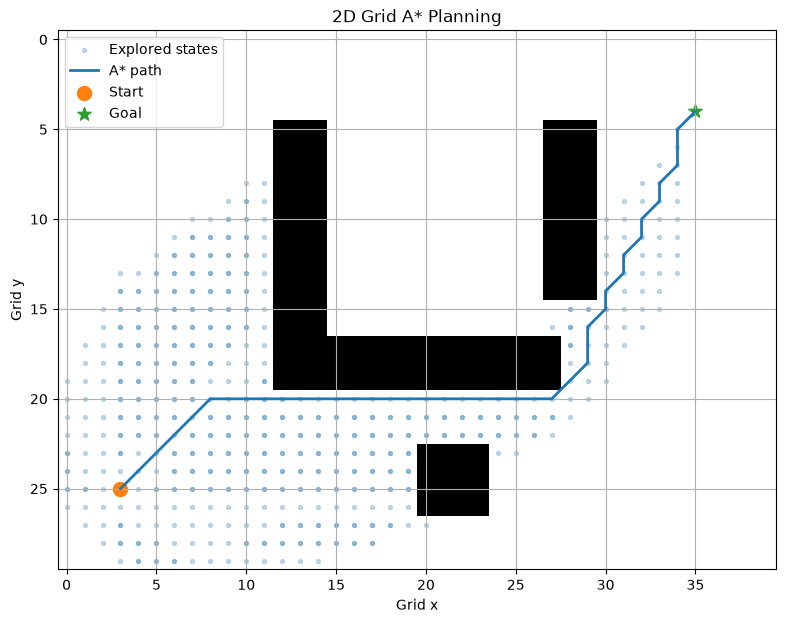

In [5]:
plt.figure(figsize=(10, 7))

plt.imshow(grid, cmap="gray_r")

# explored nodes
explored_x = [p[1] for p in explored]
explored_y = [p[0] for p in explored]

plt.scatter(
    explored_x,
    explored_y,
    s=8,
    alpha=0.25,
    label="Explored states"
)

# final path
path_x = [p[1] for p in path]
path_y = [p[0] for p in path]

plt.plot(
    path_x,
    path_y,
    linewidth=2,
    label="A* path"
)

plt.scatter(
    start[1],
    start[0],
    s=100,
    marker="o",
    label="Start"
)

plt.scatter(
    goal[1],
    goal[0],
    s=100,
    marker="*",
    label="Goal"
)

plt.xlabel("Grid x")
plt.ylabel("Grid y")

plt.title("2D Grid A* Planning")

plt.legend()
plt.grid()

plt.show()

### Observation

The grid-based A* planner successfully finds a collision-free route from the start to the goal.

However, the path is generated only using grid occupancy and distance. The planner does not know the buggy's heading, wheelbase, steering limit, or minimum turning radius.

As a result, some changes in direction can be much sharper than the physical buggy can execute.

In [6]:
def heading(p1, p2):

    dy = p2[0] - p1[0]
    dx = p2[1] - p1[1]

    return math.atan2(dy, dx)


turn_data = []

for i in range(1, len(path) - 1):

    h1 = heading(path[i-1], path[i])
    h2 = heading(path[i], path[i+1])

    change = abs(
        math.degrees(h2 - h1)
    )

    # keep angle between 0 and 180
    if change > 180:
        change = 360 - change

    turn_data.append({
        "point": path[i],
        "heading_change_deg": change
    })


sharp_turns = [
    item for item in turn_data
    if item["heading_change_deg"] >= 45
]

print("Number of sharp turns:", len(sharp_turns))

for item in sharp_turns:
    print(
        item["point"],
        round(item["heading_change_deg"], 1),
        "degrees"
    )

Number of sharp turns: 14
(20, 8) 45.0 degrees
(20, 27) 45.0 degrees
(18, 29) 45.0 degrees
(16, 29) 45.0 degrees
(15, 30) 45.0 degrees
(14, 30) 45.0 degrees
(13, 31) 45.0 degrees
(12, 31) 45.0 degrees
(11, 32) 45.0 degrees
(10, 32) 45.0 degrees
(9, 33) 45.0 degrees
(8, 33) 45.0 degrees
(7, 34) 45.0 degrees
(5, 34) 45.0 degrees


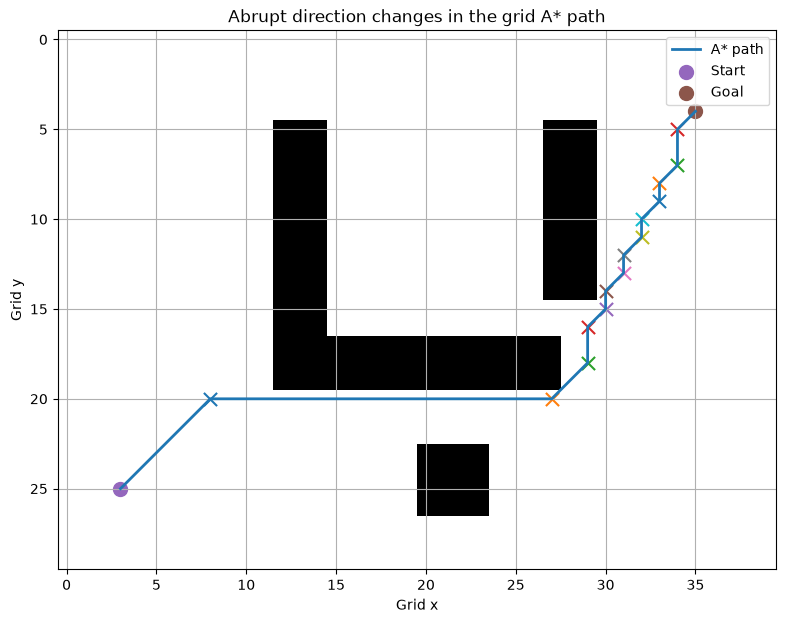

In [7]:
plt.figure(figsize=(10, 7))

plt.imshow(grid, cmap="gray_r")

plt.plot(
    path_x,
    path_y,
    linewidth=2,
    label="A* path"
)

for item in sharp_turns:

    r, c = item["point"]

    plt.scatter(
        c,
        r,
        s=90,
        marker="x"
    )

plt.scatter(
    start[1],
    start[0],
    s=100,
    label="Start"
)

plt.scatter(
    goal[1],
    goal[0],
    s=100,
    label="Goal"
)

plt.xlabel("Grid x")
plt.ylabel("Grid y")
plt.title("Abrupt direction changes in the grid A* path")

plt.legend()
plt.grid()

plt.show()

## E. Why some A* turns are not directly executable

The buggy has a minimum turning radius of approximately 3.68 m.

The grid A* path contains abrupt changes in direction between consecutive cells. In the mathematical grid, the path can change heading at a single point.

A real buggy cannot do this.

Its steering angle changes the vehicle's curvature gradually, so a turn must occupy a finite amount of space. The vehicle therefore needs a curved transition whose radius is at least approximately 3.68 m.

This demonstrates the main limitation of treating the buggy as a point robot. A collision-free grid path is not necessarily a dynamically or kinematically feasible vehicle path.

A vehicle-aware planner could fix this by including heading in the state and generating successor states using feasible steering motions. Hybrid A* is one such approach.

## F. Cost function for choosing between two collision-free paths

Suppose two paths connect the same start and goal:

- Path 1 is shorter but sharper and passes closer to obstacles.
- Path 2 is longer but smoother and keeps more clearance.

A useful planner should not choose only the shortest path. I would use a weighted cost:

\[
J =
w_L J_L +
w_C J_C +
w_O J_O +
w_S J_S
\]

where:

- \(J_L\): path-length cost
- \(J_C\): curvature or steering-effort cost
- \(J_O\): obstacle-clearance cost
- \(J_S\): steering-change cost

The weights \(w_L, w_C, w_O, w_S\) control the relative importance of each term.

### 1. Path-length cost

The simplest term is total path length:

\[
J_L = \sum_i d_i
\]

where \(d_i\) is the distance travelled between consecutive path points.

A larger \(w_L\) makes the planner prefer shorter routes.

If this term is weighted too heavily, the planner may choose a path that cuts close to obstacles or contains unnecessarily sharp turns just to save distance.

### 2. Curvature / steering-effort cost

A car-like vehicle cannot turn arbitrarily sharply.

One way to penalize sharp motion is:

\[
J_C = \sum_i \kappa_i^2
\]

where \(\kappa_i\) is the curvature of the path at point \(i\).

Higher curvature corresponds to tighter turning and therefore larger steering effort.

A larger \(w_C\) encourages smoother turns and paths that are easier for the buggy to follow.

If \(w_C\) is too large, the planner may take an unnecessarily long route just to avoid moderate curvature that the buggy could safely execute.

### 3. Obstacle-clearance cost

A path should not only avoid collision; it should also avoid passing unnecessarily close to obstacles.

A simple clearance penalty can be written as:

\[
J_O = \sum_i \frac{1}{d_{obs,i} + \epsilon}
\]

where \(d_{obs,i}\) is the distance from the path point to the nearest obstacle and \(\epsilon\) prevents division by zero.

This makes the cost large when the buggy passes close to an obstacle.

A larger \(w_O\) gives the planner more safety margin.

If \(w_O\) is too large, the planner may take very long detours even when a closer path is still safely executable.

### 4. Change in steering between consecutive steps

Even if each individual steering angle is acceptable, rapidly changing steering commands can make the ride uncomfortable and difficult to control.

A steering-change cost can be written as:

\[
J_S = \sum_i |\delta_i - \delta_{i-1}|
\]

where \(\delta_i\) is the steering command at step \(i\).

A larger \(w_S\) encourages gradual steering changes.

If \(w_S\) is too large, the planner may respond too slowly to road geometry or obstacles because it strongly resists changing steering.

## G. How the preferred path changes with speed

The relative importance of these costs should change with speed.

### At 5 km/h

At low speed, the buggy has more time to react and lateral acceleration is smaller.

A somewhat tighter path may therefore be acceptable.

The planner can give relatively more importance to path length while still respecting the minimum turning radius and obstacle-clearance constraints.

So Path 1 may be preferred if its sharper turns are still physically feasible.

### At 20 km/h

At higher speed, sharp curvature produces larger lateral acceleration and rapid steering changes become more uncomfortable and risky.

The planner should therefore increase the relative importance of:

- curvature,
- obstacle clearance,
- steering smoothness.

In this case, the longer and smoother Path 2 may be preferred even though its geometric distance is larger.

## H. Final interpretation

Normal grid A* solves only part of the planning problem.

It can answer:

**"Is there a collision-free route through the grid?"**

But it does not answer:

**"Can this particular vehicle follow that route safely and comfortably?"**

The buggy has a heading, limited steering angle, finite turning radius, and passengers onboard. These constraints must influence the planner.

For this reason, a practical vehicle planner should either:

- use a vehicle-aware search such as Hybrid A*, or
- post-process a geometric path while explicitly enforcing curvature, steering and safety constraints.

The cost function should also balance efficiency against feasibility, obstacle clearance and ride quality rather than minimizing distance alone.

In [8]:
print("Minimum turning radius:", round(min_turning_radius, 2), "m")
print("Path found:", path is not None)
print("Path points:", len(path))
print("Explored states:", len(explored))
print("Sharp direction changes:", len(sharp_turns))

Minimum turning radius: 3.68 m
Path found: True
Path points: 41
Explored states: 561
Sharp direction changes: 14
